
# Implementação e Avaliação do FixMatch com CIFAR-10

### Objetivo
Neste assignment, vocês implementarão o método FixMatch, uma técnica de aprendizado semi-supervisionado que combina aprendizado supervisionado e não supervisionado. O objetivo é aplicar o FixMatch ao dataset CIFAR-10 para treinar uma rede neural e avaliar os resultados obtidos com diferentes proporções de dados rotulados.

### 1. Introdução ao FixMatch
FixMatch é uma técnica que combina pseudo-rotulagem e consistência de dados aumentados. Em resumo, o método:
- **Gera pseudo-rótulos** para dados não rotulados, utilizando uma predição confiável de dados fracamente aumentados.
- **Aplica uma consistência de pseudo-rótulos**, onde a rede é treinada para produzir as mesmas previsões em versões fortemente aumentadas das mesmas imagens.

Para mais informações sobre a arquitetura e a metodologia do FixMatch, vocês podem consultar o [paper original](https://arxiv.org/abs/2001.07685) e/ou ver os slides disponibilizados.

### 2. Estrutura da Implementação

1. **Dataset e Preparação dos Dados**  
   - Use o CIFAR-10 como dataset.
   - Prepare duas versões dos dados:
     - **Dados rotulados:** Utilizem um subconjunto rotulado do CIFAR-10 com diferentes quantidades de rótulos por classe para experimentação.
     - **Dados não rotulados:** O restante do CIFAR-10 deve ser usado como dados não rotulados.

2. **Modelo Base**  
   - Utilize um modelo de CNN simples ou uma arquitetura pré-definida (sugestão: ResNet-18) para a implementação.

3. **Implementação do FixMatch**
   - **Pseudo-rotulagem:** Implemente a geração de rótulos para os dados não rotulados usando predições de confiança de uma versão levemente aumentada da imagem.
   - **Consistência de Augmentation:** Aplique uma versão fortemente aumentada da imagem e treine a rede para manter consistência nos pseudo-rótulos.
   - **Função de Perda**:
     - O FixMatch utiliza uma função de perda híbrida, combinando a perda supervisionada e a não supervisionada:
       - **Perda Supervisionada:** Aplique a entropia cruzada entre os rótulos reais e as predições do modelo para os dados rotulados.
       - **Perda Não Supervisionada (Consistência de Pseudo-rótulos):** Para os dados não rotulados, aplique uma entropia cruzada entre os pseudo-rótulos e as previsões das imagens aumentadas, incluindo apenas as amostras com confiança acima de um limite predefinido (threshold).
       - A função de perda final é a soma ponderada das perdas supervisionada e não supervisionada.

   - **Detalhes Importantes nas Seções 2.3 e 2.4 do paper**;

4. **Treinamento e Otimização**

### 3. Experimentos e Análise

Para avaliar o desempenho do FixMatch, vocês devem realizar experimentos com diferentes quantidades de dados rotulados. Especificamente, testem com:

1. **1 rótulo por classe** (total de 10 rótulos): Este experimento extremo explora o desempenho do FixMatch com uma quantidade mínima de dados rotulados. Observem a eficácia da técnica de pseudo-rotulagem nesse cenário.

2. **4 rótulos por classe** (total de 40 rótulos): Com um conjunto pequeno, analisem o desempenho da rede com algumas amostras rotuladas e o impacto dos pseudo-rótulos.

3. **25 rótulos por classe** (total de 250 rótulos): Esse experimento permitirá uma análise mais profunda da eficácia do FixMatch em cenários com uma quantidade moderada de rótulos.

4. **400 rótulos por classe** (total de 4.000 rótulos): Avaliem o desempenho do modelo com um conjunto mais substancial de dados rotulados, investigando o impacto da quantidade crescente de rótulos.

**Proponha pelo menos mais algum teste, fundamente sua escolha e discuta os resultados.**

Para cada experimento:
   - Treine o modelo e avalie a acurácia nos dados de teste.
   - Documente os resultados e compare a eficácia do FixMatch com a quantidade de dados rotulados disponíveis.
   - Analise o impacto dos pseudo-rótulos na qualidade do modelo, principalmente nos cenários com poucos rótulos (1, 4 e 25 rótulos por classe).

### 4. Apresentação
No final, vocês devem preparar e apresentar:

1. Slides de apresentação ou relatório:
- Explicação da implementação de cada parte do FixMatch. (simples e rápida)
- Resultados e gráficos das avaliações para os quatro cenários de rótulos por classe. (Importante)
- Análise sobre o impacto da quantidade de dados rotulados, a função de perda híbrida, e o efeito dos thresholds e data augmentation. (Importante)

2. Apresentação de 10-15 minutos
- Grave uma apresentação do seu slide/relatório cobrindo todos os pontos pedidos.

*Note que a apresentação e o conteúdo dos slides deve cobrir todos os requisitos solicitados, pois sua avaliação vai depender 90% da apresentação.



# Introdução
Implementação FixMatch - CIFAR-10

## 1. Imports e Configurações

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
from PIL import Image, ImageOps, ImageEnhance
import copy

# Configurações
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

# Seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Usando dispositivo: cuda


## Data Augmentations ( Seção 2.3 )

### Weak Augmentation
_In all of our experiments,
weak augmentation is a standard ﬂip-and-shift augmentation strategy. Speciﬁcally, we randomly
ﬂip images horizontally with a probability of 50% on all datasets except SVHN and we randomly
translate images by up to 12.5% vertically and horizontally._

In [2]:
class WeakAugmentation:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomCrop(32, padding=4, padding_mode='reflect'),  # 4/32 = 12.5%
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                               std=[0.2470, 0.2435, 0.2616])
        ])

    def __call__(self, img):
        return self.transform(img)

### Strong Augmetation
_For “strong” augmentation, we experiment with two methods based on AutoAugment [ 10 ], which are
then followed by the Cutout [14 ]._

*Weak Augmentation (leve):*
- Flip horizontal (50% probabilidade)
- Translação aleatória (até 12.5% = 4 pixels)
- Usado para gerar pseudo-labels confiáveis

*Strong Augmentation (agressiva):*
1. **RandAugment**: Escolhe aleatoriamente N=2 transformações de uma lista de 14 (Rotate, Brightness, Contrast, etc.) e aplica com magnitude aleatória
2. **Cutout**: Mascara uma região 16x16 da imagem com zeros (simula oclusão)
- Usado para treinar consistência - a rede deve prever o mesmo label mesmo com distorções fortes

#### Cutout
Cutout é uma técnica de regularização muito simples: ela "corta" (mascara) uma região quadrada aleatória da imagem, preenchendo com zeros (pixels pretos).

In [3]:
class Cutout:
    """Implementação do Cutout conforme o paper"""
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length = length

    def __call__(self, img):
        """
        Args:
            img (Tensor): Tensor image of size (C, H, W).
        Returns:
            Tensor: Image with n_holes of dimension length x length cut out of it.
        """
        h = img.size(1)
        w = img.size(2)

        mask = np.ones((h, w), np.float32)

        for n in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)

            y1 = np.clip(y - self.length // 2, 0, h)
            y2 = np.clip(y + self.length // 2, 0, h)
            x1 = np.clip(x - self.length // 2, 0, w)
            x2 = np.clip(x + self.length // 2, 0, w)

            mask[y1:y2, x1:x2] = 0.

        mask = torch.from_numpy(mask)
        mask = mask.expand_as(img)
        img = img * mask

        return img


#### RandAugment
RandAugment é uma técnica que seleciona aleatoriamente N transformações de uma lista e aplica cada uma com uma magnitude aleatória.

In [4]:
class RandAugment:
    """
    N = número de transformações a aplicar
    M = magnitude das transformações (0-30)
    """
    def __init__(self, n=2, m=10):
        self.n = n
        self.m = m
        self.augment_list = [
            self.AutoContrast,
            self.Brightness,
            self.Color,
            self.Contrast,
            self.Equalize,
            self.Identity,
            self.Posterize,
            self.Rotate,
            self.Sharpness,
            self.ShearX,
            self.ShearY,
            self.Solarize,
            self.TranslateX,
            self.TranslateY,
        ]

    def __call__(self, img):
        ops = random.choices(self.augment_list, k=self.n)
        for op in ops:
            val = (float(self.m) / 30) * random.random()
            img = op(img, val)
        return img

    def AutoContrast(self, img, _):
        return ImageOps.autocontrast(img)

    def Brightness(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Brightness(img).enhance(1 + v)

    def Color(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Color(img).enhance(1 + v)

    def Contrast(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Contrast(img).enhance(1 + v)

    def Equalize(self, img, _):
        return ImageOps.equalize(img)

    def Identity(self, img, _):
        return img

    def Posterize(self, img, v):
        assert 0 <= v <= 1
        v = int(v * 4)
        return ImageOps.posterize(img, 4 - v)

    def Rotate(self, img, v):
        assert 0 <= v <= 1
        v = v * 30  # [-30, 30] degrees
        if random.random() > 0.5:
            v = -v
        return img.rotate(v)

    def Sharpness(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Sharpness(img).enhance(1 + v)

    def ShearX(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.3
        if random.random() > 0.5:
            v = -v
        return img.transform(img.size, Image.AFFINE, (1, v, 0, 0, 1, 0))

    def ShearY(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.3
        if random.random() > 0.5:
            v = -v
        return img.transform(img.size, Image.AFFINE, (1, 0, 0, v, 1, 0))

    def Solarize(self, img, v):
        assert 0 <= v <= 1
        return ImageOps.solarize(img, int(256 * (1 - v)))

    def TranslateX(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.33  # 33% of image width
        if random.random() > 0.5:
            v = -v
        v = int(v * img.size[0])
        return img.transform(img.size, Image.AFFINE, (1, 0, v, 0, 1, 0))

    def TranslateY(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.33  # 33% of image height
        if random.random() > 0.5:
            v = -v
        v = int(v * img.size[1])
        return img.transform(img.size, Image.AFFINE, (1, 0, 0, 0, 1, v))


#### StrongAugmentation

In [5]:
class StrongAugmentation:
    """Strong augmentation: RandAugment seguido de Cutout"""
    def __init__(self, n=2, m=10):
        self.randaugment = RandAugment(n=n, m=m)
        self.cutout = Cutout(n_holes=1, length=16)
        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                               std=[0.2470, 0.2435, 0.2616])
        ])

    def __call__(self, img):
        # Aplica RandAugment
        img = self.randaugment(img)
        # Converte para tensor e normaliza
        img = self.normalize(img)
        # Aplica Cutout
        img = self.cutout(img)
        return img


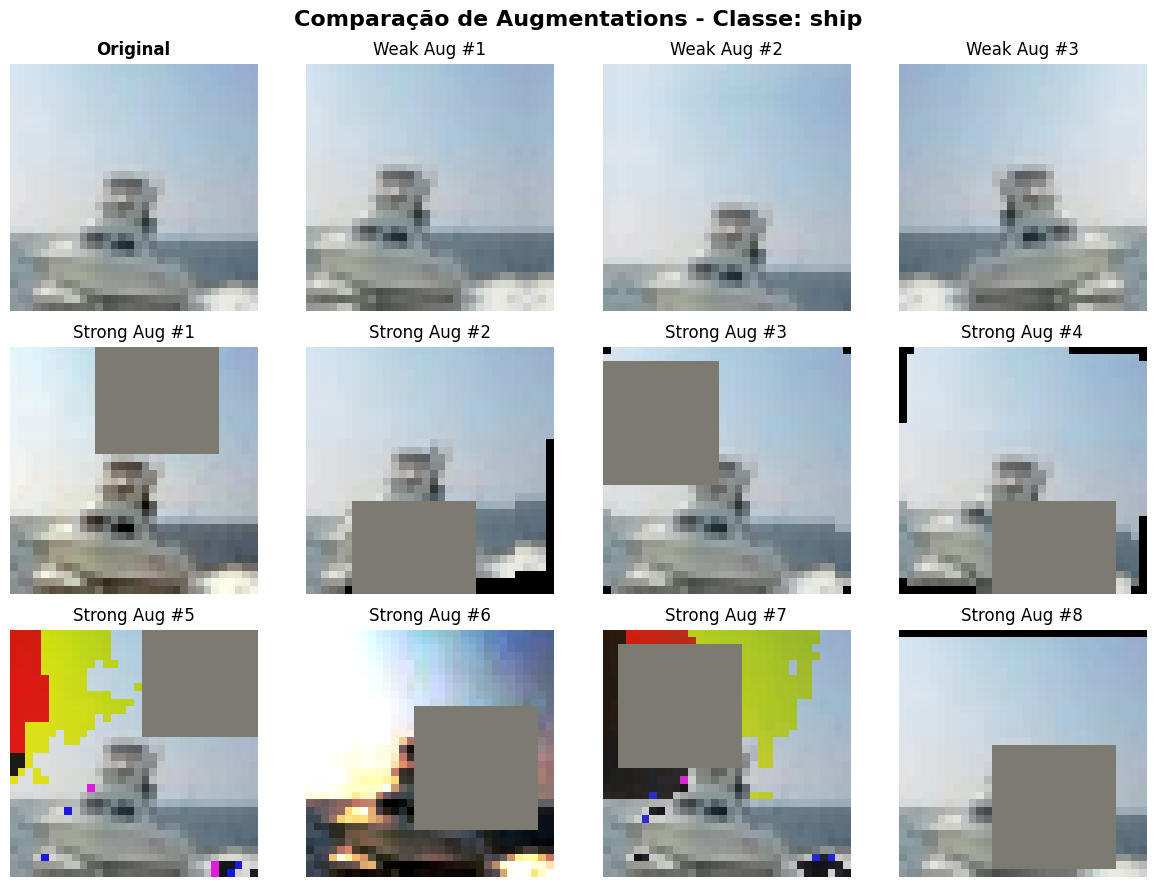


📊 Observações:
• Weak Aug: Modificações leves - apenas flip e translação
• Strong Aug: Modificações agressivas - rotação, cores, brilho, cutout (quadrados pretos)
• Cada Strong Aug é diferente devido à aleatoriedade do RandAugment


In [6]:
# Visualização das Augmentations
# Carregar uma imagem de exemplo do CIFAR-10

# Download CIFAR-10 (apenas para visualização)
transform_base = transforms.Compose([transforms.ToTensor()])
cifar10_sample = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)

# Pegar uma imagem de exemplo
sample_idx = 100
sample_img, sample_label = cifar10_sample[sample_idx]
sample_img_pil = transforms.ToPILImage()(sample_img)

# Classes do CIFAR-10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Criar augmentations
weak_aug = WeakAugmentation()
strong_aug = StrongAugmentation()

# Função para desnormalizar imagem para visualização
def denormalize(tensor, mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]):
    """Desnormaliza um tensor para visualização"""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

# Gerar várias versões da mesma imagem
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle(f'Comparação de Augmentations - Classe: {classes[sample_label]}', fontsize=16, fontweight='bold')

# Linha 1: Original + 3 Weak Augmentations
axes[0, 0].imshow(sample_img.permute(1, 2, 0))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 4):
    weak_img = weak_aug(sample_img_pil)
    weak_img_denorm = denormalize(weak_img)
    axes[0, i].imshow(weak_img_denorm.permute(1, 2, 0))
    axes[0, i].set_title(f'Weak Aug #{i}')
    axes[0, i].axis('off')

# Linha 2: 4 Strong Augmentations
for i in range(4):
    strong_img = strong_aug(sample_img_pil)
    strong_img_denorm = denormalize(strong_img)
    axes[1, i].imshow(strong_img_denorm.permute(1, 2, 0))
    axes[1, i].set_title(f'Strong Aug #{i+1}')
    axes[1, i].axis('off')

# Linha 3: Mais 4 Strong Augmentations para mostrar variabilidade
for i in range(4):
    strong_img = strong_aug(sample_img_pil)
    strong_img_denorm = denormalize(strong_img)
    axes[2, i].imshow(strong_img_denorm.permute(1, 2, 0))
    axes[2, i].set_title(f'Strong Aug #{i+5}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Observações:")
print("• Weak Aug: Modificações leves - apenas flip e translação")
print("• Strong Aug: Modificações agressivas - rotação, cores, brilho, cutout (quadrados pretos)")
print("• Cada Strong Aug é diferente devido à aleatoriedade do RandAugment")

## 3. Dataset Loader com Split Rotulado/Não-Rotulado

O FixMatch precisa de dois tipos de dados:
- **Dados rotulados**: Pequeno conjunto com labels conhecidos (usado para loss supervisionada)
- **Dados não-rotulados**: Grande conjunto sem labels (usado para pseudo-labeling e loss não-supervisionada)

Vamos criar funções para:
1. Dividir o CIFAR-10 em rotulado/não-rotulado
2. Criar datasets customizados que aplicam weak e strong augmentations

### Labeled Dataset

In [7]:
class LabeledDataset(Dataset):
    """
    Dataset para dados rotulados.
    Aplica apenas weak augmentation.
    """
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform if transform is not None else WeakAugmentation()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Pegar imagem e label do dataset base
        real_idx = self.indices[idx]
        img_tensor, label = self.base_dataset[real_idx]

        # Converter tensor de volta para PIL para aplicar augmentation
        img_pil = transforms.ToPILImage()(img_tensor)

        # Aplicar weak augmentation
        img_augmented = self.transform(img_pil)

        return img_augmented, label


### Unlabeled Dataset

In [8]:
class UnlabeledDataset(Dataset):
    """
    Dataset para dados não-rotulados.
    Retorna DUAS versões da mesma imagem:
    - Weak augmentation (para gerar pseudo-label)
    - Strong augmentation (para treinar consistência)
    """
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices
        self.weak_transform = WeakAugmentation()
        self.strong_transform = StrongAugmentation()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Pegar imagem do dataset base
        real_idx = self.indices[idx]
        img_tensor, _ = self.base_dataset[real_idx]  # Ignoramos o label

        # Converter tensor para PIL
        img_pil = transforms.ToPILImage()(img_tensor)

        # Aplicar weak e strong augmentations na MESMA imagem
        img_weak = self.weak_transform(img_pil)
        img_strong = self.strong_transform(img_pil)

        return img_weak, img_strong

In [9]:
def split_labeled_unlabeled(dataset, num_labels_per_class, num_classes=10):
    """
    Divide o dataset em conjuntos rotulado e não-rotulado.

    Args:
        dataset: Dataset original (CIFAR-10)
        num_labels_per_class: Número de exemplos rotulados por classe
        num_classes: Número de classes (10 para CIFAR-10)

    Returns:
        labeled_indices: Índices dos dados rotulados
        unlabeled_indices: Índices dos dados não-rotulados
    """
    # Organizar índices por classe
    labels = np.array([dataset[i][1] for i in range(len(dataset))])

    labeled_indices = []
    unlabeled_indices = []

    for class_idx in range(num_classes):
        # Encontrar todos os índices desta classe
        class_indices = np.where(labels == class_idx)[0]

        # Embaralhar para seleção aleatória
        np.random.shuffle(class_indices)

        # Separar em rotulado e não-rotulado
        labeled_indices.extend(class_indices[:num_labels_per_class])
        unlabeled_indices.extend(class_indices[num_labels_per_class:])

    return labeled_indices, unlabeled_indices


# Carregar CIFAR-10 sem transformações (já foi carregado anteriormente)
base_dataset = cifar10_sample

for num_labels in [1, 4, 25, 400]:
    labeled_idx, unlabeled_idx = split_labeled_unlabeled(base_dataset, num_labels)
    print(f"• {num_labels} labels/classe:")
    print(f"  - Rotulados: {len(labeled_idx)} exemplos ({num_labels * 10})")
    print(f"  - Não-rotulados: {len(unlabeled_idx)} exemplos")
    print()

• 1 labels/classe:
  - Rotulados: 10 exemplos (10)
  - Não-rotulados: 49990 exemplos

• 4 labels/classe:
  - Rotulados: 40 exemplos (40)
  - Não-rotulados: 49960 exemplos

• 25 labels/classe:
  - Rotulados: 250 exemplos (250)
  - Não-rotulados: 49750 exemplos

• 400 labels/classe:
  - Rotulados: 4000 exemplos (4000)
  - Não-rotulados: 46000 exemplos



In [10]:
def create_dataloaders(num_labels_per_class, batch_size=64, num_workers=2):
    """
    Cria DataLoaders para treino com FixMatch.

    Args:
        num_labels_per_class: Número de exemplos rotulados por classe
        batch_size: Tamanho do batch
        num_workers: Número de workers para carregamento

    Returns:
        labeled_loader: DataLoader com dados rotulados
        unlabeled_loader: DataLoader com dados não-rotulados
        test_loader: DataLoader com dados de teste
    """
    # Carregar dataset base
    transform_base = transforms.Compose([transforms.ToTensor()])

    train_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=transform_base
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                               std=[0.2470, 0.2435, 0.2616])
        ])
    )

    # Split rotulado/não-rotulado
    labeled_indices, unlabeled_indices = split_labeled_unlabeled(
        train_dataset,
        num_labels_per_class
    )

    # Criar datasets customizados
    labeled_dataset = LabeledDataset(train_dataset, labeled_indices)
    unlabeled_dataset = UnlabeledDataset(train_dataset, unlabeled_indices)

    # Criar DataLoaders
    labeled_loader = DataLoader(
        labeled_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=False  # Alterado para False para garantir que labeled_loader não seja vazio com poucos exemplos
    )

    unlabeled_loader = DataLoader(
        unlabeled_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    print(f"✓ DataLoaders criados para {num_labels_per_class} labels/classe:")
    print(f"  - Labeled batches: {len(labeled_loader)}")
    print(f"  - Unlabeled batches: {len(unlabeled_loader)}")
    print(f"  - Test batches: {len(test_loader)}")

    return labeled_loader, unlabeled_loader, test_loader



## 4. Modelo Base - ResNet-18

Vamos usar o ResNet-18 do torchvision, adaptado para CIFAR-10 (imagens 32x32).

**Modificações necessárias:**
- Trocar a primeira camada convolucional (de 7x7 para 3x3, stride 1)
- Remover o MaxPooling inicial
- Ajustar a camada final para 10 classes (CIFAR-10)

In [11]:
import torchvision.models as models

def get_resnet18_cifar10(num_classes=10):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# Criar modelo
model = get_resnet18_cifar10(num_classes=10).to(device)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Modelo ResNet-18 (torchvision) CIFAR-10:")
print(f"  - Total de parâmetros: {total_params:,}")
print(f"  - Parâmetros treináveis: {trainable_params:,}")
print(f"  - Dispositivo: {device}")

Modelo ResNet-18 (torchvision) CIFAR-10:
  - Total de parâmetros: 11,173,962
  - Parâmetros treináveis: 11,173,962
  - Dispositivo: cuda


## 5. Função de Perda Híbrida do FixMatch

O FixMatch utiliza uma função de perda que combina:

1. **Loss Supervisionada (Ls)**: Cross-entropy nos dados rotulados
   - `Ls = CrossEntropy(modelo(x_labeled), y_true)`

2. **Loss Não-Supervisionada (Lu)**: Consistência de pseudo-labels
   - Gera pseudo-label na versão weak: `pseudo_label = argmax(modelo(x_weak))`
   - Aplica loss na versão strong: `Lu = CrossEntropy(modelo(x_strong), pseudo_label)`
   - **Apenas se confiança > threshold** (ex: max(prob) > 0.95)

3. **Loss Total**: `L = Ls + λu * Lu`
   - λu é o peso da loss não-supervisionada (geralmente 1.0)

In [12]:
def fixmatch_loss(logits_labeled, labels, logits_unlabeled_weak, logits_unlabeled_strong,
                  threshold=0.95, lambda_u=1.0):
    """
    Calcula a loss híbrida do FixMatch.

    Args:
        logits_labeled: Logits do modelo para dados rotulados (batch_size, num_classes)
        labels: Labels verdadeiros dos dados rotulados (batch_size,)
        logits_unlabeled_weak: Logits para versão weak dos dados não-rotulados
        logits_unlabeled_strong: Logits para versão strong dos dados não-rotulados
        threshold: Threshold de confiança para pseudo-labels (padrão: 0.95)
        lambda_u: Peso da loss não-supervisionada (padrão: 1.0)

    Returns:
        loss_total: Loss total (supervisionada + não-supervisionada)
        loss_supervised: Loss supervisionada
        loss_unsupervised: Loss não-supervisionada
        mask_ratio: Proporção de amostras não-rotuladas acima do threshold
    """
    # ===== 1. LOSS SUPERVISIONADA =====
    # Cross-entropy padrão nos dados rotulados
    loss_supervised = F.cross_entropy(logits_labeled, labels)

    # ===== 2. LOSS NÃO-SUPERVISIONADA (PSEUDO-LABELING) =====
    # Gerar pseudo-labels da versão weak
    with torch.no_grad():
        # Calcular probabilidades (softmax)
        probs_weak = F.softmax(logits_unlabeled_weak, dim=1)

        # Pegar a classe com maior probabilidade
        max_probs, pseudo_labels = torch.max(probs_weak, dim=1)

        # Criar máscara: apenas amostras com confiança > threshold
        mask = max_probs >= threshold

    # Calcular loss apenas nas amostras que passaram no threshold
    if mask.sum() > 0:
        # Cross-entropy entre predição strong e pseudo-label
        loss_unsupervised = F.cross_entropy(
            logits_unlabeled_strong[mask],
            pseudo_labels[mask]
        )
    else:
        # Se nenhuma amostra passou no threshold, loss = 0
        loss_unsupervised = torch.tensor(0.0).to(logits_labeled.device)

    # ===== 3. LOSS TOTAL =====
    loss_total = loss_supervised + lambda_u * loss_unsupervised

    # Calcular proporção de amostras usadas (para monitoramento)
    mask_ratio = mask.float().mean().item()

    return loss_total, loss_supervised, loss_unsupervised, mask_ratio



## 6. Função de Avaliação

Função para avaliar a acurácia do modelo no conjunto de teste.

In [13]:
@torch.no_grad()
def evaluate(model, test_loader, device):
    """
    Avalia o modelo no conjunto de teste.

    Args:
        model: Modelo a ser avaliado
        test_loader: DataLoader com dados de teste
        device: Dispositivo (CPU ou CUDA)

    Returns:
        accuracy: Acurácia no conjunto de teste (%)
    """
    model.eval()

    correct = 0
    total = 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total

    return accuracy


print("✓ Função de avaliação implementada")

✓ Função de avaliação implementada


## 7. Loop de Treinamento FixMatch

Implementação do loop de treinamento completo do FixMatch.

In [14]:
def train_fixmatch(model, labeled_loader, unlabeled_loader, test_loader,
                   num_epochs=100, lr=0.03, threshold=0.95, lambda_u=1.0, device='cpu'):
    """
    Treina o modelo usando o algoritmo FixMatch.

    Args:
        model: Modelo a ser treinado
        labeled_loader: DataLoader com dados rotulados
        unlabeled_loader: DataLoader com dados não-rotulados
        test_loader: DataLoader com dados de teste
        num_epochs: Número de épocas
        lr: Learning rate
        threshold: Threshold de confiança para pseudo-labels
        lambda_u: Peso da loss não-supervisionada
        device: Dispositivo (CPU ou CUDA)

    Returns:
        history: Dicionário com histórico de treinamento
    """
    # Configurar otimizador e scheduler
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

    # Cosine annealing scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Histórico
    history = {
        'train_loss': [],
        'train_loss_supervised': [],
        'train_loss_unsupervised': [],
        'mask_ratio': [],
        'test_accuracy': [],
        'learning_rate': []
    }

    # Loop de treinamento
    for epoch in range(num_epochs):
        model.train()

        # Métricas da época
        epoch_loss = 0.0
        epoch_loss_sup = 0.0
        epoch_loss_unsup = 0.0
        epoch_mask_ratio = 0.0
        num_batches = 0

        # Iteradores
        labeled_iter = iter(labeled_loader)
        unlabeled_iter = iter(unlabeled_loader)

        # Número de iterações = min(labeled_batches, unlabeled_batches)
        num_iterations = min(len(labeled_loader), len(unlabeled_loader))

        pbar = tqdm(range(num_iterations), desc=f'Epoch {epoch+1}/{num_epochs}')

        for _ in pbar:
            # ===== PEGAR BATCHES =====
            try:
                # Dados rotulados
                images_labeled, labels_labeled = next(labeled_iter)
            except StopIteration:
                labeled_iter = iter(labeled_loader)
                images_labeled, labels_labeled = next(labeled_iter)

            try:
                # Dados não-rotulados (weak e strong)
                images_unlabeled_weak, images_unlabeled_strong = next(unlabeled_iter)
            except StopIteration:
                unlabeled_iter = iter(unlabeled_loader)
                images_unlabeled_weak, images_unlabeled_strong = next(unlabeled_iter)

            # Mover para device
            images_labeled = images_labeled.to(device)
            labels_labeled = labels_labeled.to(device)
            images_unlabeled_weak = images_unlabeled_weak.to(device)
            images_unlabeled_strong = images_unlabeled_strong.to(device)

            # ===== FORWARD PASS =====
            # Dados rotulados
            logits_labeled = model(images_labeled)

            # Dados não-rotulados (weak e strong)
            logits_unlabeled_weak = model(images_unlabeled_weak)
            logits_unlabeled_strong = model(images_unlabeled_strong)

            # ===== CALCULAR LOSS =====
            loss, loss_sup, loss_unsup, mask_ratio = fixmatch_loss(
                logits_labeled, labels_labeled,
                logits_unlabeled_weak, logits_unlabeled_strong,
                threshold=threshold, lambda_u=lambda_u
            )

            # ===== BACKWARD PASS =====
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # ===== ACUMULAR MÉTRICAS =====
            epoch_loss += loss.item()
            epoch_loss_sup += loss_sup.item()
            epoch_loss_unsup += loss_unsup.item()
            epoch_mask_ratio += mask_ratio
            num_batches += 1

            # Atualizar progress bar
            pbar.set_postfix({
                'Loss': f'{loss.item():.3f}',
                'Ls': f'{loss_sup.item():.3f}',
                'Lu': f'{loss_unsup.item():.3f}',
                'Mask': f'{mask_ratio:.2%}'
            })

        # ===== ATUALIZAR SCHEDULER =====
        scheduler.step()

        # ===== CALCULAR MÉDIAS DA ÉPOCA =====
        avg_loss = epoch_loss / num_batches
        avg_loss_sup = epoch_loss_sup / num_batches
        avg_loss_unsup = epoch_loss_unsup / num_batches
        avg_mask_ratio = epoch_mask_ratio / num_batches

        # ===== AVALIAR NO CONJUNTO DE TESTE =====
        test_acc = evaluate(model, test_loader, device)

        # ===== SALVAR HISTÓRICO =====
        history['train_loss'].append(avg_loss)
        history['train_loss_supervised'].append(avg_loss_sup)
        history['train_loss_unsupervised'].append(avg_loss_unsup)
        history['mask_ratio'].append(avg_mask_ratio)
        history['test_accuracy'].append(test_acc)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        # ===== PRINT RESUMO DA ÉPOCA =====
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Loss: {avg_loss:.4f} (Sup: {avg_loss_sup:.4f}, Unsup: {avg_loss_unsup:.4f})')
        print(f'  Mask Ratio: {avg_mask_ratio:.2%}')
        print(f'  Test Accuracy: {test_acc:.2f}%')
        print(f'  LR: {optimizer.param_groups[0]["lr"]:.6f}')
        print('-' * 60)

    return history


print("✓ Função de treinamento FixMatch implementada")

✓ Função de treinamento FixMatch implementada


## 8. Experimentos

### Experimento 1: 1 Rótulo por Classe (Total: 10 rótulos)

Este experimento extremo explora o desempenho do FixMatch com a quantidade mínima de dados rotulados. Vamos observar a eficácia da técnica de pseudo-rotulagem nesse cenário desafiador.

In [15]:
# ===== CONFIGURAÇÕES DO EXPERIMENTO 1 =====
NUM_LABELS_PER_CLASS = 1
BATCH_SIZE = 256
NUM_EPOCHS = 50
LEARNING_RATE = 0.03
THRESHOLD = 0.95
LAMBDA_U = 1.0

print("="*60)
print("EXPERIMENTO 1: 1 RÓTULO POR CLASSE")
print("="*60)
print(f"Configurações:")
print(f"  - Rótulos por classe: {NUM_LABELS_PER_CLASS}")
print(f"  - Total de rótulos: {NUM_LABELS_PER_CLASS * 10}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Épocas: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Threshold: {THRESHOLD}")
print(f"  - Lambda_u: {LAMBDA_U}")
print("="*60)
print()

# ===== CRIAR DATALOADERS =====
print("Criando DataLoaders...")
labeled_loader_1, unlabeled_loader_1, test_loader_1 = create_dataloaders(
    num_labels_per_class=NUM_LABELS_PER_CLASS,
    batch_size=BATCH_SIZE,
    num_workers=0  # Usar 0 para evitar problemas no Windows
)
print()

# ===== CRIAR MODELO =====
print("Criando modelo ResNet-18...")
model_1label = get_resnet18_cifar10(num_classes=10).to(device)
print(f"Modelo criado no dispositivo: {device}")
print()

# ===== TREINAR MODELO =====
print("Iniciando treinamento...")
print("="*60)

history_1label = train_fixmatch(
    model=model_1label,
    labeled_loader=labeled_loader_1,
    unlabeled_loader=unlabeled_loader_1,
    test_loader=test_loader_1,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    threshold=THRESHOLD,
    lambda_u=LAMBDA_U,
    device=device
)

print("="*60)
print("TREINAMENTO CONCLUÍDO!")
print(f"Acurácia final no teste: {history_1label['test_accuracy'][-1]:.2f}%")
print("="*60)

EXPERIMENTO 1: 1 RÓTULO POR CLASSE
Configurações:
  - Rótulos por classe: 1
  - Total de rótulos: 10
  - Batch size: 256
  - Épocas: 50
  - Learning rate: 0.03
  - Threshold: 0.95
  - Lambda_u: 1.0

Criando DataLoaders...
✓ DataLoaders criados para 1 labels/classe:
  - Labeled batches: 1
  - Unlabeled batches: 195
  - Test batches: 40

Criando modelo ResNet-18...
Modelo criado no dispositivo: cuda

Iniciando treinamento...


Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s, Loss=2.445, Ls=2.445, Lu=0.000, Mask=0.00%]


Epoch 1/50:
  Loss: 2.4445 (Sup: 2.4445, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 9.70%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  2.11it/s, Loss=2.093, Ls=2.093, Lu=0.000, Mask=0.00%]


Epoch 2/50:
  Loss: 2.0925 (Sup: 2.0925, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 10.01%
  LR: 0.029882
------------------------------------------------------------


...

Epoch 48/50:
  Loss: 0.6055 (Sup: 0.1468, Unsup: 0.4586)
  Mask Ratio: 41.80%
  Test Accuracy: 16.40%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.55it/s, Loss=0.823, Ls=0.096, Lu=0.727, Mask=41.02%]


Epoch 49/50:
  Loss: 0.8233 (Sup: 0.0961, Unsup: 0.7272)
  Mask Ratio: 41.02%
  Test Accuracy: 16.21%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s, Loss=1.097, Ls=0.173, Lu=0.924, Mask=41.80%]


Epoch 50/50:
  Loss: 1.0974 (Sup: 0.1730, Unsup: 0.9244)
  Mask Ratio: 41.80%
  Test Accuracy: 16.30%
  LR: 0.000000
------------------------------------------------------------
TREINAMENTO CONCLUÍDO!
Acurácia final no teste: 16.30%


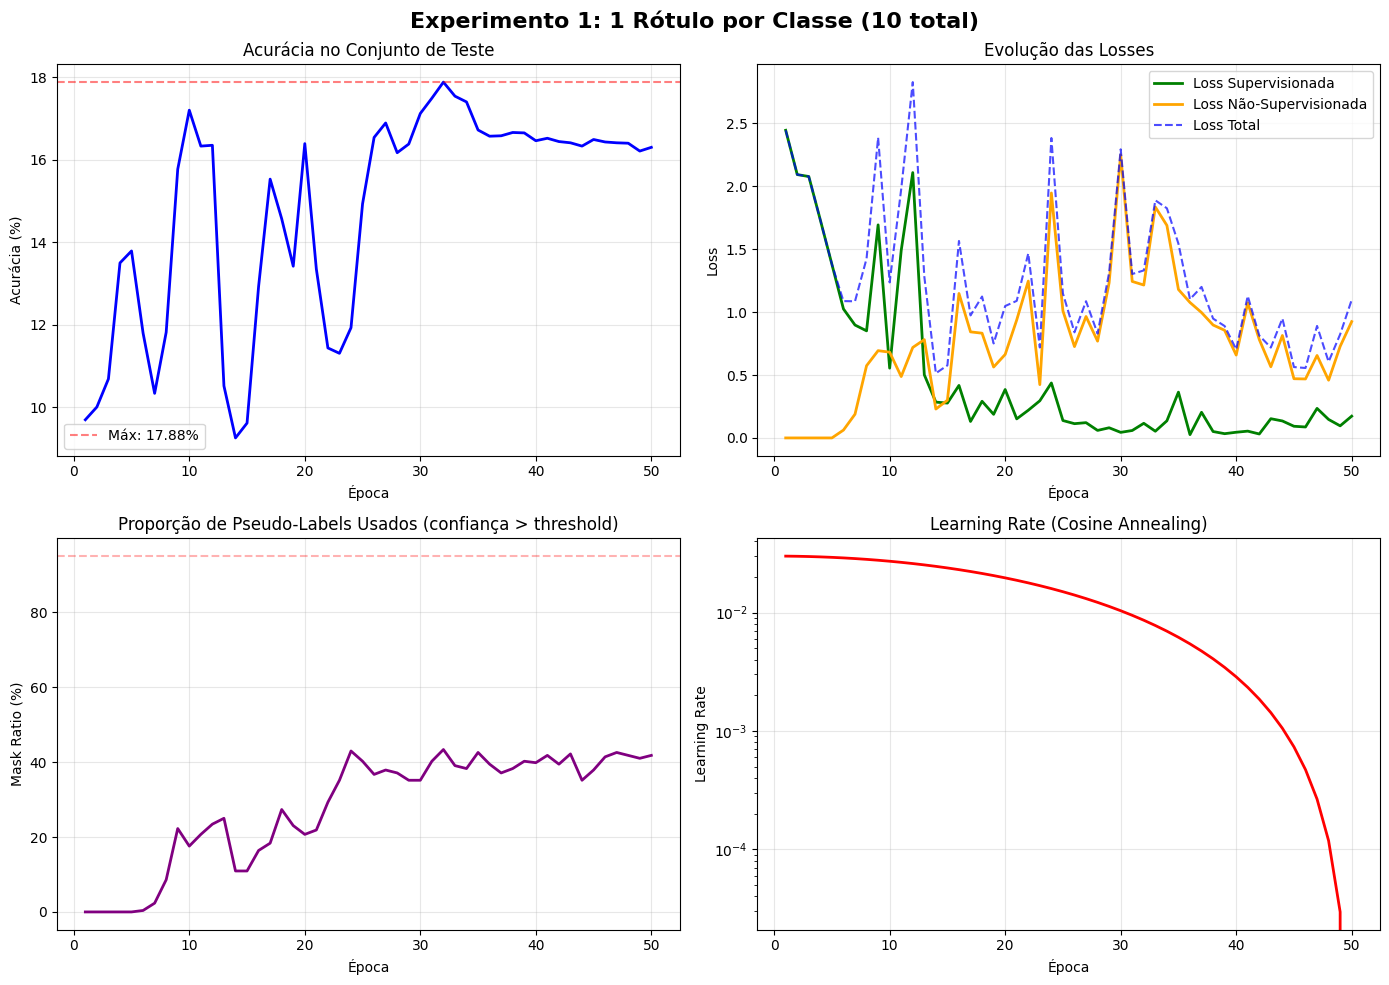


RESUMO DO EXPERIMENTO 1: 1 RÓTULO POR CLASSE
Acurácia Inicial: 9.70%
Acurácia Final: 16.30%
Acurácia Máxima: 17.88%
Melhoria: +6.60%

Mask Ratio Final: 41.80%
Loss Final: 1.0974


In [16]:
# Visualizar resultados do Experimento 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experimento 1: 1 Rótulo por Classe (10 total)', fontsize=16, fontweight='bold')

epochs = range(1, len(history_1label['test_accuracy']) + 1)

# 1. Acurácia no Teste
axes[0, 0].plot(epochs, history_1label['test_accuracy'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Acurácia (%)')
axes[0, 0].set_title('Acurácia no Conjunto de Teste')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=max(history_1label['test_accuracy']), color='r', linestyle='--',
                    alpha=0.5, label=f'Máx: {max(history_1label["test_accuracy"]):.2f}%')
axes[0, 0].legend()

# 2. Losses (Supervisionada vs Não-supervisionada)
axes[0, 1].plot(epochs, history_1label['train_loss_supervised'], 'g-', linewidth=2, label='Loss Supervisionada')
axes[0, 1].plot(epochs, history_1label['train_loss_unsupervised'], 'orange', linewidth=2, label='Loss Não-Supervisionada')
axes[0, 1].plot(epochs, history_1label['train_loss'], 'b--', linewidth=1.5, label='Loss Total', alpha=0.7)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Evolução das Losses')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mask Ratio (% de amostras não-rotuladas usadas)
axes[1, 0].plot(epochs, [m * 100 for m in history_1label['mask_ratio']], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Mask Ratio (%)')
axes[1, 0].set_title('Proporção de Pseudo-Labels Usados (confiança > threshold)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=95, color='r', linestyle='--', alpha=0.3, label='Threshold = 95%')

# 4. Learning Rate
axes[1, 1].plot(epochs, history_1label['learning_rate'], 'red', linewidth=2)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate (Cosine Annealing)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Resumo estatístico
print("\n" + "="*60)
print("RESUMO DO EXPERIMENTO 1: 1 RÓTULO POR CLASSE")
print("="*60)
print(f"Acurácia Inicial: {history_1label['test_accuracy'][0]:.2f}%")
print(f"Acurácia Final: {history_1label['test_accuracy'][-1]:.2f}%")
print(f"Acurácia Máxima: {max(history_1label['test_accuracy']):.2f}%")
print(f"Melhoria: +{history_1label['test_accuracy'][-1] - history_1label['test_accuracy'][0]:.2f}%")
print(f"\nMask Ratio Final: {history_1label['mask_ratio'][-1]:.2%}")
print(f"Loss Final: {history_1label['train_loss'][-1]:.4f}")
print("="*60)

In [17]:
# Salvar modelo e histórico
import pickle

# Criar diretório para salvar resultados
import os
os.makedirs('results', exist_ok=True)

# Salvar modelo
torch.save(model_1label.state_dict(), 'results/model_1label.pth')
print("✓ Modelo salvo em: results/model_1label.pth")

# Salvar histórico
with open('results/history_1label.pkl', 'wb') as f:
    pickle.dump(history_1label, f)
print("✓ Histórico salvo em: results/history_1label.pkl")

✓ Modelo salvo em: results/model_1label.pth
✓ Histórico salvo em: results/history_1label.pkl


In [18]:
# ===== CONFIGURAÇÕES DO EXPERIMENTO 2 =====
NUM_LABELS_PER_CLASS = 4
BATCH_SIZE = 256
NUM_EPOCHS = 50
LEARNING_RATE = 0.03
THRESHOLD = 0.95
LAMBDA_U = 1.0

print("="*60)
print("EXPERIMENTO 2: 4 RÓTULOS POR CLASSE")
print("="*60)
print(f"Configurações:")
print(f"  - Rótulos por classe: {NUM_LABELS_PER_CLASS}")
print(f"  - Total de rótulos: {NUM_LABELS_PER_CLASS * 10}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Épocas: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Threshold: {THRESHOLD}")
print(f"  - Lambda_u: {LAMBDA_U}")
print("="*60)
print()

# ===== CRIAR DATALOADERS =====
print("Criando DataLoaders...")
labeled_loader_4, unlabeled_loader_4, test_loader_4 = create_dataloaders(
    num_labels_per_class=NUM_LABELS_PER_CLASS,
    batch_size=BATCH_SIZE,
    num_workers=0
)
print()

# ===== CRIAR MODELO =====
print("Criando modelo ResNet-18...")
model_4label = get_resnet18_cifar10(num_classes=10).to(device)
print(f"Modelo criado no dispositivo: {device}")
print()

# ===== TREINAR MODELO =====
print("Iniciando treinamento...")
print("="*60)

history_4label = train_fixmatch(
    model=model_4label,
    labeled_loader=labeled_loader_4,
    unlabeled_loader=unlabeled_loader_4,
    test_loader=test_loader_4,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    threshold=THRESHOLD,
    lambda_u=LAMBDA_U,
    device=device
)

print("="*60)
print("TREINAMENTO CONCLUÍDO!")
print(f"Acurácia final no teste: {history_4label['test_accuracy'][-1]:.2f}%")
print("="*60)

EXPERIMENTO 2: 4 RÓTULOS POR CLASSE
Configurações:
  - Rótulos por classe: 4
  - Total de rótulos: 40
  - Batch size: 256
  - Épocas: 50
  - Learning rate: 0.03
  - Threshold: 0.95
  - Lambda_u: 1.0

Criando DataLoaders...
✓ DataLoaders criados para 4 labels/classe:
  - Labeled batches: 1
  - Unlabeled batches: 195
  - Test batches: 40

Criando modelo ResNet-18...
Modelo criado no dispositivo: cuda

Iniciando treinamento...


Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s, Loss=2.433, Ls=2.433, Lu=0.000, Mask=0.00%]


Epoch 1/50:
  Loss: 2.4326 (Sup: 2.4326, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 11.36%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.85it/s, Loss=2.260, Ls=2.260, Lu=0.000, Mask=0.00%]


Epoch 2/50:
  Loss: 2.2601 (Sup: 2.2601, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 11.34%
  LR: 0.029882
------------------------------------------------------------


...

Epoch 48/50:
  Loss: 0.9604 (Sup: 0.3581, Unsup: 0.6023)
  Mask Ratio: 18.36%
  Test Accuracy: 21.17%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.48it/s, Loss=0.696, Ls=0.408, Lu=0.288, Mask=16.41%]


Epoch 49/50:
  Loss: 0.6959 (Sup: 0.4082, Unsup: 0.2878)
  Mask Ratio: 16.41%
  Test Accuracy: 21.16%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s, Loss=0.864, Ls=0.364, Lu=0.500, Mask=20.70%]


Epoch 50/50:
  Loss: 0.8641 (Sup: 0.3644, Unsup: 0.4997)
  Mask Ratio: 20.70%
  Test Accuracy: 21.12%
  LR: 0.000000
------------------------------------------------------------
TREINAMENTO CONCLUÍDO!
Acurácia final no teste: 21.12%


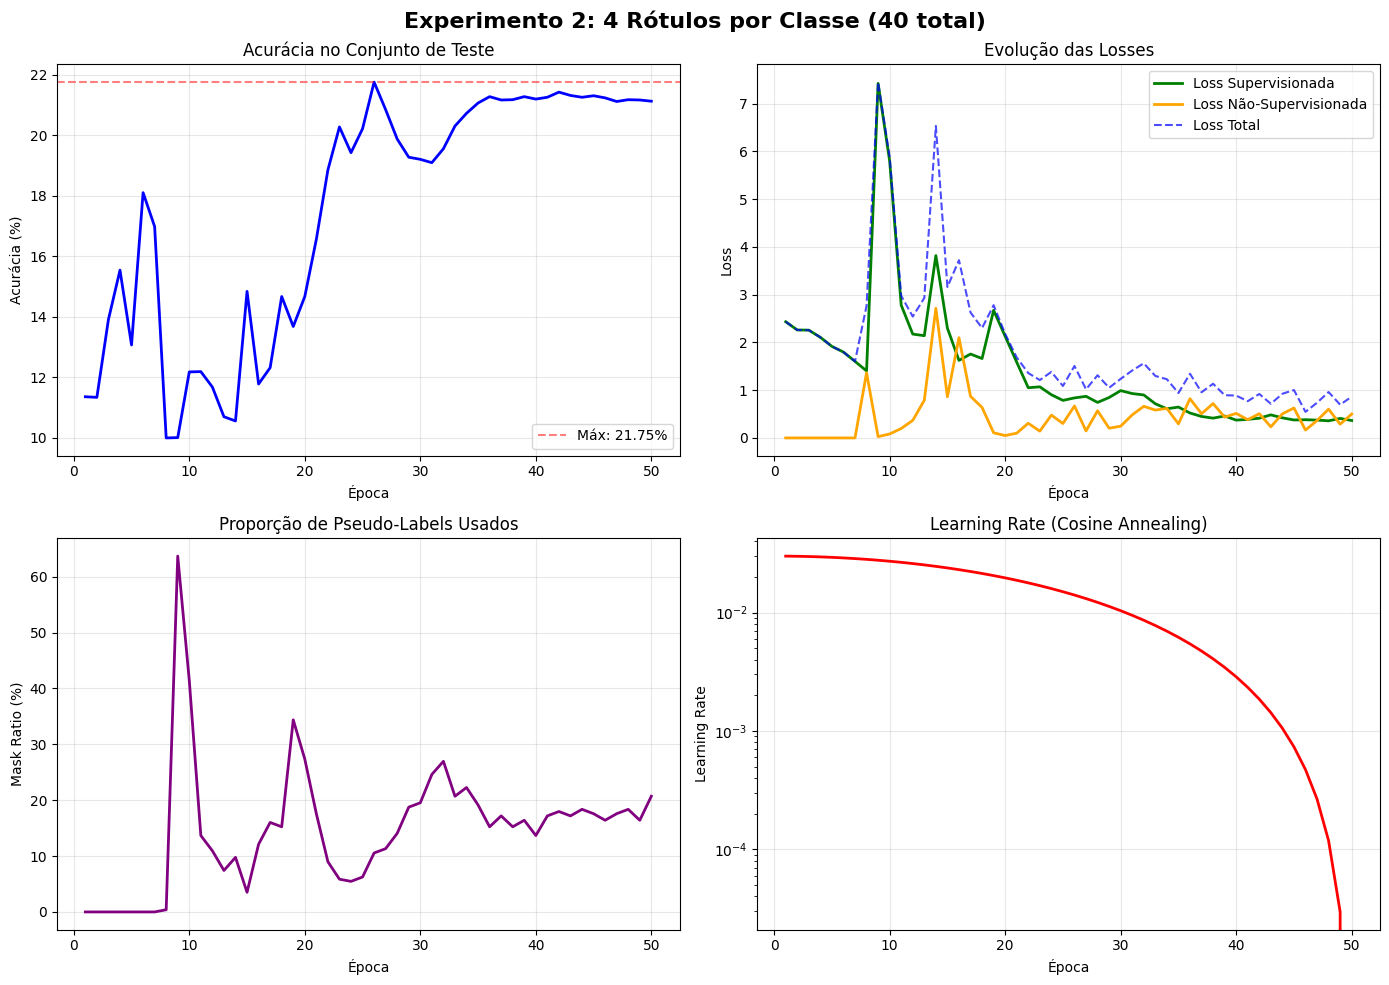


RESUMO DO EXPERIMENTO 2: 4 RÓTULOS POR CLASSE
Acurácia Inicial: 11.36%
Acurácia Final: 21.12%
Acurácia Máxima: 21.75%
Melhoria: +9.76%

Mask Ratio Final: 20.70%
Loss Final: 0.8641


In [19]:
# Visualizar resultados do Experimento 2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experimento 2: 4 Rótulos por Classe (40 total)', fontsize=16, fontweight='bold')

epochs = range(1, len(history_4label['test_accuracy']) + 1)

# 1. Acurácia no Teste
axes[0, 0].plot(epochs, history_4label['test_accuracy'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Acurácia (%)')
axes[0, 0].set_title('Acurácia no Conjunto de Teste')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=max(history_4label['test_accuracy']), color='r', linestyle='--',
                    alpha=0.5, label=f'Máx: {max(history_4label["test_accuracy"]):.2f}%')
axes[0, 0].legend()

# 2. Losses
axes[0, 1].plot(epochs, history_4label['train_loss_supervised'], 'g-', linewidth=2, label='Loss Supervisionada')
axes[0, 1].plot(epochs, history_4label['train_loss_unsupervised'], 'orange', linewidth=2, label='Loss Não-Supervisionada')
axes[0, 1].plot(epochs, history_4label['train_loss'], 'b--', linewidth=1.5, label='Loss Total', alpha=0.7)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Evolução das Losses')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mask Ratio
axes[1, 0].plot(epochs, [m * 100 for m in history_4label['mask_ratio']], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Mask Ratio (%)')
axes[1, 0].set_title('Proporção de Pseudo-Labels Usados')
axes[1, 0].grid(True, alpha=0.3)

# 4. Learning Rate
axes[1, 1].plot(epochs, history_4label['learning_rate'], 'red', linewidth=2)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate (Cosine Annealing)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Resumo
print("\n" + "="*60)
print("RESUMO DO EXPERIMENTO 2: 4 RÓTULOS POR CLASSE")
print("="*60)
print(f"Acurácia Inicial: {history_4label['test_accuracy'][0]:.2f}%")
print(f"Acurácia Final: {history_4label['test_accuracy'][-1]:.2f}%")
print(f"Acurácia Máxima: {max(history_4label['test_accuracy']):.2f}%")
print(f"Melhoria: +{history_4label['test_accuracy'][-1] - history_4label['test_accuracy'][0]:.2f}%")
print(f"\nMask Ratio Final: {history_4label['mask_ratio'][-1]:.2%}")
print(f"Loss Final: {history_4label['train_loss'][-1]:.4f}")
print("="*60)

In [20]:
# Salvar modelo e histórico do Experimento 2
torch.save(model_4label.state_dict(), 'results/model_4label.pth')
with open('results/history_4label.pkl', 'wb') as f:
    pickle.dump(history_4label, f)
print("✓ Experimento 2 salvo em results/")

✓ Experimento 2 salvo em results/


In [21]:
# ===== CONFIGURAÇÕES DO EXPERIMENTO 3 =====
NUM_LABELS_PER_CLASS = 25
BATCH_SIZE = 256
NUM_EPOCHS = 50
LEARNING_RATE = 0.03
THRESHOLD = 0.9
LAMBDA_U = 1.0

print("="*60)
print("EXPERIMENTO 3: 25 RÓTULOS POR CLASSE")
print("="*60)
print(f"Configurações:")
print(f"  - Rótulos por classe: {NUM_LABELS_PER_CLASS}")
print(f"  - Total de rótulos: {NUM_LABELS_PER_CLASS * 10}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Épocas: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Threshold: {THRESHOLD}")
print(f"  - Lambda_u: {LAMBDA_U}")
print("="*60)
print()

# ===== CRIAR DATALOADERS =====
print("Criando DataLoaders...")
labeled_loader_25, unlabeled_loader_25, test_loader_25 = create_dataloaders(
    num_labels_per_class=NUM_LABELS_PER_CLASS,
    batch_size=BATCH_SIZE,
    num_workers=0
)
print()

# ===== CRIAR MODELO =====
print("Criando modelo ResNet-18...")
model_25label = get_resnet18_cifar10(num_classes=10).to(device)
print(f"Modelo criado no dispositivo: {device}")
print()

# ===== TREINAR MODELO =====
print("Iniciando treinamento...")
print("="*60)

history_25label = train_fixmatch(
    model=model_25label,
    labeled_loader=labeled_loader_25,
    unlabeled_loader=unlabeled_loader_25,
    test_loader=test_loader_25,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    threshold=THRESHOLD,
    lambda_u=LAMBDA_U,
    device=device
)

print("="*60)
print("TREINAMENTO CONCLUÍDO!")
print(f"Acurácia final no teste: {history_25label['test_accuracy'][-1]:.2f}%")
print("="*60)

EXPERIMENTO 3: 25 RÓTULOS POR CLASSE
Configurações:
  - Rótulos por classe: 25
  - Total de rótulos: 250
  - Batch size: 256
  - Épocas: 50
  - Learning rate: 0.03
  - Threshold: 0.9
  - Lambda_u: 1.0

Criando DataLoaders...
✓ DataLoaders criados para 25 labels/classe:
  - Labeled batches: 1
  - Unlabeled batches: 194
  - Test batches: 40

Criando modelo ResNet-18...
Modelo criado no dispositivo: cuda

Iniciando treinamento...


Epoch 1/50: 100%|██████████| 1/1 [00:01<00:00,  1.03s/it, Loss=2.397, Ls=2.397, Lu=0.000, Mask=0.00%]


Epoch 1/50:
  Loss: 2.3968 (Sup: 2.3968, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 10.41%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s, Loss=2.304, Ls=2.304, Lu=0.000, Mask=0.00%]


Epoch 2/50:
  Loss: 2.3038 (Sup: 2.3038, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 10.53%
  LR: 0.029882
------------------------------------------------------------


...

Epoch 48/50:
  Loss: 2.3906 (Sup: 1.9855, Unsup: 0.4051)
  Mask Ratio: 7.42%
  Test Accuracy: 23.38%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.00it/s, Loss=2.777, Ls=2.047, Lu=0.730, Mask=11.72%]


Epoch 49/50:
  Loss: 2.7767 (Sup: 2.0466, Unsup: 0.7301)
  Mask Ratio: 11.72%
  Test Accuracy: 23.59%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.00it/s, Loss=2.175, Ls=2.024, Lu=0.151, Mask=12.11%]


Epoch 50/50:
  Loss: 2.1753 (Sup: 2.0241, Unsup: 0.1512)
  Mask Ratio: 12.11%
  Test Accuracy: 23.74%
  LR: 0.000000
------------------------------------------------------------
TREINAMENTO CONCLUÍDO!
Acurácia final no teste: 23.74%


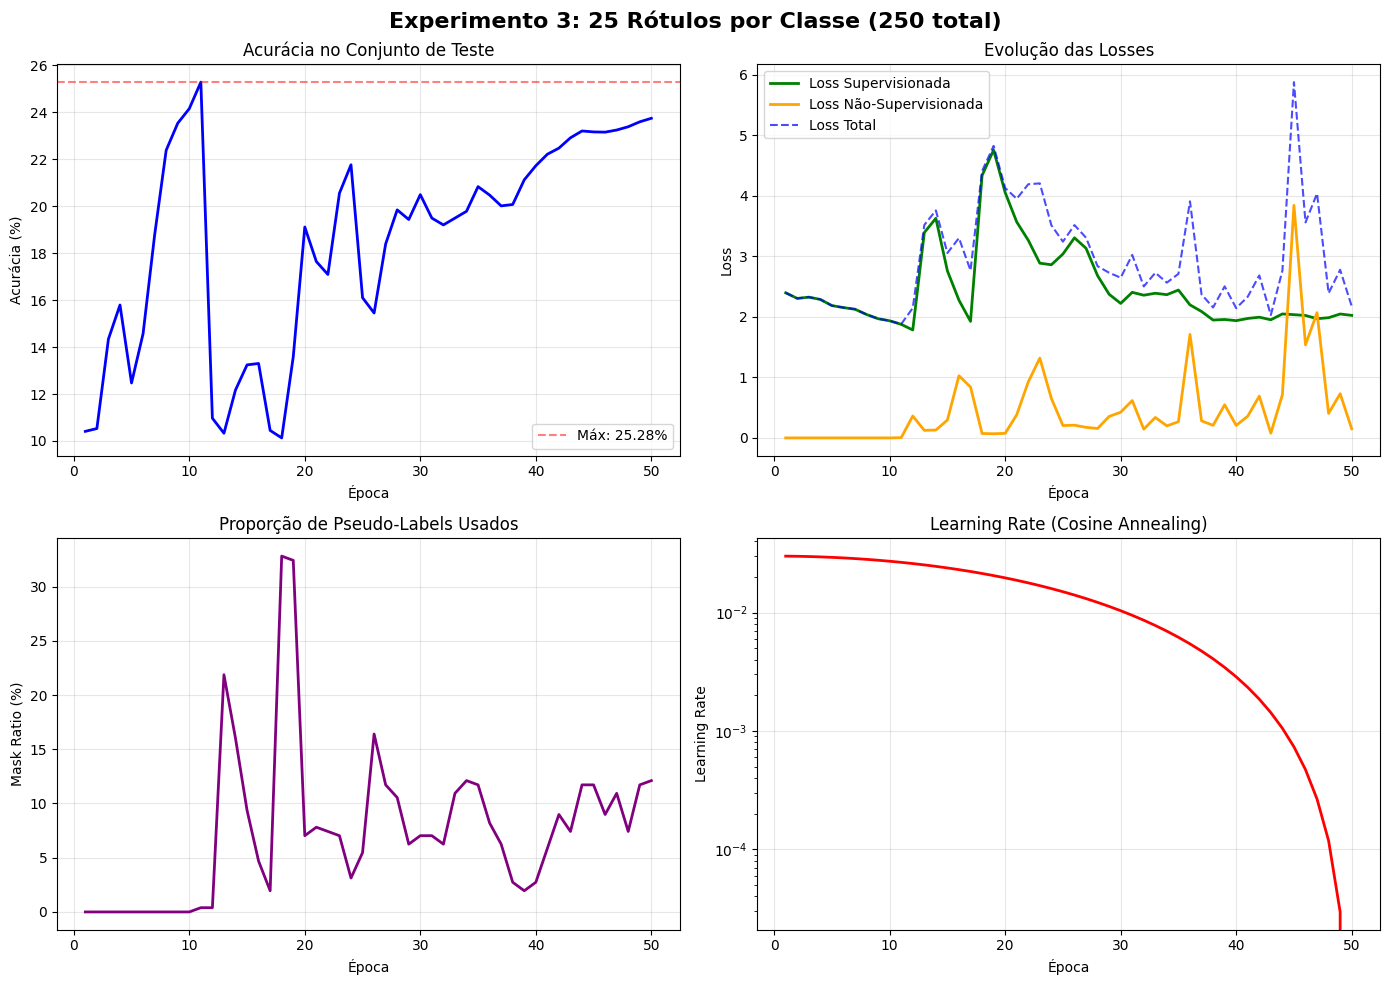


RESUMO DO EXPERIMENTO 3: 25 RÓTULOS POR CLASSE
Acurácia Inicial: 10.41%
Acurácia Final: 23.74%
Acurácia Máxima: 25.28%
Melhoria: +13.33%

Mask Ratio Final: 12.11%
Loss Final: 2.1753


In [22]:
# Visualizar resultados do Experimento 3
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experimento 3: 25 Rótulos por Classe (250 total)', fontsize=16, fontweight='bold')

epochs = range(1, len(history_25label['test_accuracy']) + 1)

# 1. Acurácia no Teste
axes[0, 0].plot(epochs, history_25label['test_accuracy'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Acurácia (%)')
axes[0, 0].set_title('Acurácia no Conjunto de Teste')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=max(history_25label['test_accuracy']), color='r', linestyle='--',
                    alpha=0.5, label=f'Máx: {max(history_25label["test_accuracy"]):.2f}%')
axes[0, 0].legend()

# 2. Losses
axes[0, 1].plot(epochs, history_25label['train_loss_supervised'], 'g-', linewidth=2, label='Loss Supervisionada')
axes[0, 1].plot(epochs, history_25label['train_loss_unsupervised'], 'orange', linewidth=2, label='Loss Não-Supervisionada')
axes[0, 1].plot(epochs, history_25label['train_loss'], 'b--', linewidth=1.5, label='Loss Total', alpha=0.7)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Evolução das Losses')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mask Ratio
axes[1, 0].plot(epochs, [m * 100 for m in history_25label['mask_ratio']], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Mask Ratio (%)')
axes[1, 0].set_title('Proporção de Pseudo-Labels Usados')
axes[1, 0].grid(True, alpha=0.3)

# 4. Learning Rate
axes[1, 1].plot(epochs, history_25label['learning_rate'], 'red', linewidth=2)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate (Cosine Annealing)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Resumo
print("\n" + "="*60)
print("RESUMO DO EXPERIMENTO 3: 25 RÓTULOS POR CLASSE")
print("="*60)
print(f"Acurácia Inicial: {history_25label['test_accuracy'][0]:.2f}%")
print(f"Acurácia Final: {history_25label['test_accuracy'][-1]:.2f}%")
print(f"Acurácia Máxima: {max(history_25label['test_accuracy']):.2f}%")
print(f"Melhoria: +{history_25label['test_accuracy'][-1] - history_25label['test_accuracy'][0]:.2f}%")
print(f"\nMask Ratio Final: {history_25label['mask_ratio'][-1]:.2%}")
print(f"Loss Final: {history_25label['train_loss'][-1]:.4f}")
print("="*60)

In [23]:
# Salvar modelo e histórico do Experimento 3
torch.save(model_25label.state_dict(), 'results/model_25label.pth')
with open('results/history_25label.pkl', 'wb') as f:
    pickle.dump(history_25label, f)
print("✓ Experimento 3 salvo em results/")

✓ Experimento 3 salvo em results/


In [24]:
# ===== CONFIGURAÇÕES DO EXPERIMENTO 4 =====
NUM_LABELS_PER_CLASS = 400
BATCH_SIZE = 256
NUM_EPOCHS = 50
LEARNING_RATE = 0.03
THRESHOLD = 0.95
LAMBDA_U = 1.0

print("="*60)
print("EXPERIMENTO 4: 400 RÓTULOS POR CLASSE")
print("="*60)
print(f"Configurações:")
print(f"  - Rótulos por classe: {NUM_LABELS_PER_CLASS}")
print(f"  - Total de rótulos: {NUM_LABELS_PER_CLASS * 10}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Épocas: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Threshold: {THRESHOLD}")
print(f"  - Lambda_u: {LAMBDA_U}")
print("="*60)
print()

# ===== CRIAR DATALOADERS =====
print("Criando DataLoaders...")
labeled_loader_400, unlabeled_loader_400, test_loader_400 = create_dataloaders(
    num_labels_per_class=NUM_LABELS_PER_CLASS,
    batch_size=BATCH_SIZE,
    num_workers=0
)
print()

# ===== CRIAR MODELO =====
print("Criando modelo ResNet-18...")
model_400label = get_resnet18_cifar10(num_classes=10).to(device)
print(f"Modelo criado no dispositivo: {device}")
print()

# ===== TREINAR MODELO =====
print("Iniciando treinamento...")
print("="*60)

history_400label = train_fixmatch(
    model=model_400label,
    labeled_loader=labeled_loader_400,
    unlabeled_loader=unlabeled_loader_400,
    test_loader=test_loader_400,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    threshold=THRESHOLD,
    lambda_u=LAMBDA_U,
    device=device
)

print("="*60)
print("TREINAMENTO CONCLUÍDO!")
print(f"Acurácia final no teste: {history_400label['test_accuracy'][-1]:.2f}%")
print("="*60)

EXPERIMENTO 4: 400 RÓTULOS POR CLASSE
Configurações:
  - Rótulos por classe: 400
  - Total de rótulos: 4000
  - Batch size: 256
  - Épocas: 50
  - Learning rate: 0.03
  - Threshold: 0.95
  - Lambda_u: 1.0

Criando DataLoaders...
✓ DataLoaders criados para 400 labels/classe:
  - Labeled batches: 16
  - Unlabeled batches: 179
  - Test batches: 40

Criando modelo ResNet-18...
Modelo criado no dispositivo: cuda

Iniciando treinamento...


Epoch 1/50: 100%|██████████| 16/16 [00:14<00:00,  1.10it/s, Loss=5.756, Ls=5.507, Lu=0.249, Mask=15.23%]


Epoch 1/50:
  Loss: 2.7083 (Sup: 2.6484, Unsup: 0.0599)
  Mask Ratio: 3.47%
  Test Accuracy: 10.10%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 16/16 [00:17<00:00,  1.07s/it, Loss=3.011, Ls=3.002, Lu=0.009, Mask=4.30%]


Epoch 2/50:
  Loss: 3.1607 (Sup: 2.9951, Unsup: 0.1656)
  Mask Ratio: 4.71%
  Test Accuracy: 21.85%
  LR: 0.029882
------------------------------------------------------------


...

Epoch 48/50:
  Loss: 1.1434 (Sup: 0.8971, Unsup: 0.2462)
  Mask Ratio: 15.70%
  Test Accuracy: 60.50%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 16/16 [00:16<00:00,  1.02s/it, Loss=0.958, Ls=0.784, Lu=0.174, Mask=18.36%]


Epoch 49/50:
  Loss: 1.1142 (Sup: 0.8966, Unsup: 0.2177)
  Mask Ratio: 16.53%
  Test Accuracy: 60.44%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 16/16 [00:16<00:00,  1.05s/it, Loss=0.997, Ls=0.823, Lu=0.174, Mask=14.45%]


Epoch 50/50:
  Loss: 1.1201 (Sup: 0.8991, Unsup: 0.2210)
  Mask Ratio: 16.48%
  Test Accuracy: 60.24%
  LR: 0.000000
------------------------------------------------------------
TREINAMENTO CONCLUÍDO!
Acurácia final no teste: 60.24%


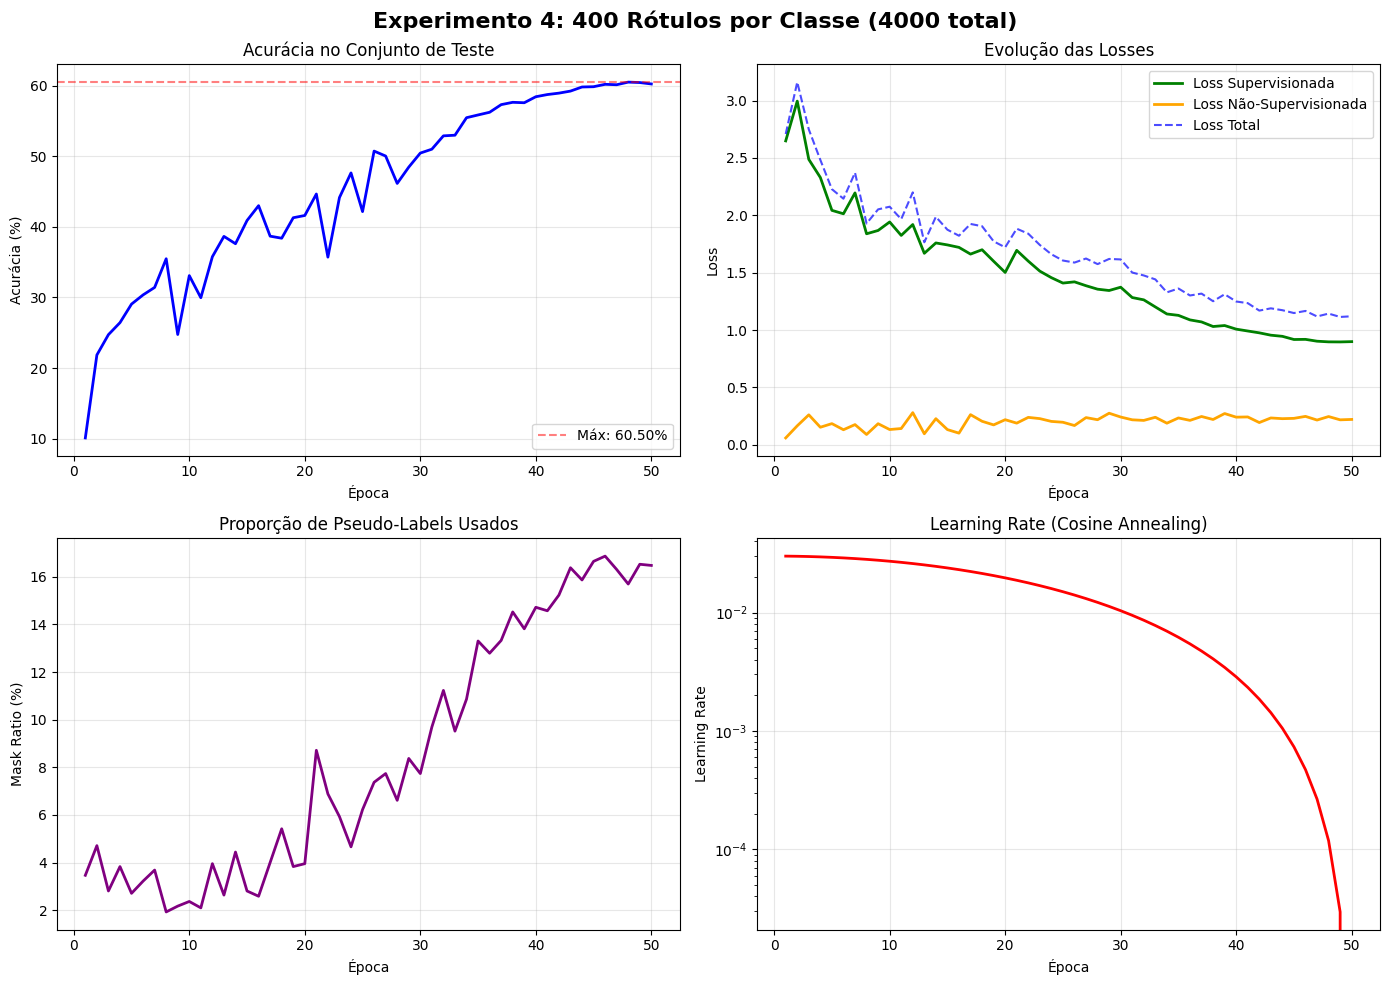


RESUMO DO EXPERIMENTO 4: 400 RÓTULOS POR CLASSE
Acurácia Inicial: 10.10%
Acurácia Final: 60.24%
Acurácia Máxima: 60.50%
Melhoria: +50.14%

Mask Ratio Final: 16.48%
Loss Final: 1.1201


In [25]:
# Visualizar resultados do Experimento 4
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experimento 4: 400 Rótulos por Classe (4000 total)', fontsize=16, fontweight='bold')

epochs = range(1, len(history_400label['test_accuracy']) + 1)

# 1. Acurácia no Teste
axes[0, 0].plot(epochs, history_400label['test_accuracy'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Acurácia (%)')
axes[0, 0].set_title('Acurácia no Conjunto de Teste')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=max(history_400label['test_accuracy']), color='r', linestyle='--',
                    alpha=0.5, label=f'Máx: {max(history_400label["test_accuracy"]):.2f}%')
axes[0, 0].legend()

# 2. Losses
axes[0, 1].plot(epochs, history_400label['train_loss_supervised'], 'g-', linewidth=2, label='Loss Supervisionada')
axes[0, 1].plot(epochs, history_400label['train_loss_unsupervised'], 'orange', linewidth=2, label='Loss Não-Supervisionada')
axes[0, 1].plot(epochs, history_400label['train_loss'], 'b--', linewidth=1.5, label='Loss Total', alpha=0.7)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Evolução das Losses')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mask Ratio
axes[1, 0].plot(epochs, [m * 100 for m in history_400label['mask_ratio']], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Mask Ratio (%)')
axes[1, 0].set_title('Proporção de Pseudo-Labels Usados')
axes[1, 0].grid(True, alpha=0.3)

# 4. Learning Rate
axes[1, 1].plot(epochs, history_400label['learning_rate'], 'red', linewidth=2)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate (Cosine Annealing)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Resumo
print("\n" + "="*60)
print("RESUMO DO EXPERIMENTO 4: 400 RÓTULOS POR CLASSE")
print("="*60)
print(f"Acurácia Inicial: {history_400label['test_accuracy'][0]:.2f}%")
print(f"Acurácia Final: {history_400label['test_accuracy'][-1]:.2f}%")
print(f"Acurácia Máxima: {max(history_400label['test_accuracy']):.2f}%")
print(f"Melhoria: +{history_400label['test_accuracy'][-1] - history_400label['test_accuracy'][0]:.2f}%")
print(f"\nMask Ratio Final: {history_400label['mask_ratio'][-1]:.2%}")
print(f"Loss Final: {history_400label['train_loss'][-1]:.4f}")
print("="*60)

In [26]:
# Salvar modelo e histórico do Experimento 4
torch.save(model_400label.state_dict(), 'results/model_400label.pth')
with open('results/history_400label.pkl', 'wb') as f:
    pickle.dump(history_400label, f)
print("✓ Experimento 4 salvo em results/")

✓ Experimento 4 salvo em results/
